In [13]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Find the project root that contains the src folder
current = Path.cwd().resolve()

for p in [current] + list(current.parents):
    if (p / "src").exists():
        repo_root = p
        break
else:
    raise FileNotFoundError("Could not find a folder containing 'src'.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Current working directory:", current)
print("Added repo root:", repo_root)
print("src exists:", (repo_root / "src").exists())

from pathlib import Path
import numpy as np
import pandas as pd

import src.utils.pdata_io as pdio
from src.proc.extract_epoch_windows import load_epoch_windows

data_root, pdata_root, cc_data = pdio.load_project_context()

windows_df = load_epoch_windows(
    pdata_root=pdata_root,
    filename="behavior_epoch_windows.h5",
    key="windows/prepost_1s"
)

valid_windows = windows_df[windows_df["valid_window"]].copy()

print("All windows:", windows_df.shape)
print("Valid windows:", valid_windows.shape)

valid_windows.groupby(["phase", "epoch_name"]).size().reset_index(name="n_windows")

encoder_epoch_df = pd.read_hdf(
    Path(pdata_root) / "_cache" / "behavior_epoch_metrics.h5",
    key="encoder/prepost_1s_speedThresh_1cms"
)

from src.qc.qc_events import load_behavior_qc_tables

events_df, session_summary_df = load_behavior_qc_tables(
    pdata_root=pdata_root,
    filename="behavior_QC.h5"
)

from pathlib import Path

# Make figures folder inside pdata directory
fig_dir = Path(pdata_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Convert to string for R compatibility
fig_dir_str = str(fig_dir)
fig_dir

Current working directory: /home/nmldata2/ccaw/Python/notebooks
Added repo root: /home/nmldata2/ccaw/Python
src exists: True
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
[LOADED] Epoch windows: /mnt/pdata/Classical_Conditioning/_cache/behavior_epoch_windows.h5
[KEY] windows/prepost_1s
All windows: (103980, 40)
Valid windows: (101861, 40)
[LOADED] Behavior QC tables: /mnt/pdata/Classical_Conditioning/_cache/behavior_QC.h5


PosixPath('/mnt/pdata/Classical_Conditioning/figures')

In [14]:
encoder_epoch_df.columns.tolist()

['animal',
 'date',
 'phase',
 'event_number',
 'anchor_name',
 'anchor_type',
 'anchor_time_s',
 'window_position',
 'window_s',
 'epoch_name',
 'window_start_s',
 'window_end_s',
 'start_idx',
 'end_idx',
 'on_time_s',
 'off_time_s',
 'next_on_time_s',
 'on_duration_s',
 'off_duration_s',
 'session_duration_s',
 'session_time_bin',
 'parent_event_valid',
 'valid_window_basic',
 'valid_window',
 'overlap_flag',
 'overlap_s',
 'overlap_with',
 'anchor_warning',
 'invalid_reason',
 'good_session_basic',
 'rig_day_from_date',
 'rig_session_number',
 'phase_day_from_date',
 'phase_session_number',
 'rig_session_start_min',
 'phase_session_start_min',
 'recording_duration_min',
 'anchor_session_time_min',
 'anchor_rig_time_min',
 'anchor_phase_time_min',
 'speed_thresh_cms',
 'fs',
 'n_samples_window',
 'mean_speed_path_cms',
 'median_speed_path_cms',
 'peak_speed_path_cms',
 'mean_speed_net_cms',
 'median_speed_net_cms',
 'min_speed_net_cms',
 'max_speed_net_cms',
 'distance_path_cm',
 'd

In [177]:
%connect_info

{"key":"8fc4457c-4483-4ec3-b55c-b08e900f0984","signature_scheme":"hmac-sha256","transport":"tcp","ip":"127.0.0.1","hb_port":9000,"control_port":9001,"shell_port":9002,"stdin_port":9003,"iopub_port":9004,"kernel_name":"python3820jvsc74a57bd07f6243129cfff82ede3c5c59589229000c07b9cd1160ea9b86b0dd361ed08050"}

Paste the above JSON into a file, and connect with:
    $> jupyter <app> --existing <file>
or, if you are local, you can connect with just:
    $> jupyter <app> --existing /run/user/1000/jupyter/runtime/kernel-v365c51bbedcb8a1eb99d32767840a52be41f02e01.json
or even just:
    $> jupyter <app> --existing
if this is the most recent Jupyter kernel you have started.


In [197]:
from src.utils.pdata_organize import make_anchor_window_table

tone_on_delta_df = make_anchor_window_table(
    encoder_epoch_df,
    phase="tone_air_training",
    anchor_name="tone_on",
    return_type="delta",
    keep_overlap=True,
)

tone_on_delta_df.head()

,animal,date,phase,event_number,anchor_name,anchor_type,rig_day_from_date,rig_session_number,phase_day_from_date,phase_session_number,...,delta_mean_speed_net_cms,delta_median_speed_net_cms,delta_distance_path_cm,delta_distance_net_cm,delta_frac_stationary,delta_frac_moving,delta_frac_forward,delta_frac_backward,delta_frac_low_net_movement,delta_net_direction_bias
0,NML_04,2026_01_28,tone_air_training,0,tone_on,main,33,32,1,1,...,-1.877868,-2.261947,-1.156106,-1.859823,0.3986,-0.3986,-0.6664,0.2678,0.0,-0.802958
1,NML_04,2026_01_28,tone_air_training,1,tone_on,main,33,32,1,1,...,0.100531,0.000000,-0.150796,0.100531,0.0678,-0.0678,0.0000,-0.0678,0.0,1.605327
2,NML_04,2026_01_28,tone_air_training,2,tone_on,main,33,32,1,1,...,-0.072332,0.000000,0.125664,-0.075398,-0.0404,0.0404,0.0000,0.0404,0.0,-0.700243
3,NML_04,2026_01_28,tone_air_training,3,tone_on,main,33,32,1,1,...,-0.042474,0.251327,0.050265,0.000000,0.1990,-0.1990,-0.1990,0.0000,0.0,-0.036362
4,NML_04,2026_01_28,tone_air_training,4,tone_on,main,33,32,1,1,...,0.025133,0.000000,-0.025133,0.025133,0.0000,0.0000,0.0000,0.0000,0.0,1.000000


In [200]:
from src.utils.pdata_organize import make_anchor_window_table
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf


tone_on_long_df = make_anchor_window_table(
    encoder_epoch_df,
    phase="tone_air_training",
    anchor_name="tone_on",
    return_type="long",
    keep_overlap=True,
)

tone_on_long_df.head()

,animal,date,phase,event_number,anchor_name,anchor_type,anchor_time_s,window_position,window_s,epoch_name,...,max_speed_net_cms,distance_path_cm,distance_net_cm,net_direction_bias,frac_stationary,frac_moving,frac_forward,frac_backward,frac_low_net_movement,dominant_locomotor_state
0,NML_04,2026_01_28,tone_air_training,0,tone_on,main,39.981602,post,1.0,tone_on_post_1s,...,2.764602,0.879646,0.175929,0.197042,0.4828,0.5172,0.2494,0.2678,0.0,stationary
1,NML_04,2026_01_28,tone_air_training,0,tone_on,main,39.981602,pre,1.0,tone_on_pre_1s,...,3.015929,2.035752,2.035752,1.000000,0.0842,0.9158,0.9158,0.0000,0.0,forward
2,NML_04,2026_01_28,tone_air_training,1,tone_on,main,83.921799,post,1.0,tone_on_post_1s,...,0.251327,0.025133,0.025133,1.000000,1.0000,0.0000,0.0000,0.0000,0.0,stationary
3,NML_04,2026_01_28,tone_air_training,1,tone_on,main,83.921799,pre,1.0,tone_on_pre_1s,...,0.251327,0.175929,-0.075398,-0.605327,0.9322,0.0678,0.0000,0.0678,0.0,stationary
4,NML_04,2026_01_28,tone_air_training,2,tone_on,main,115.761398,post,1.0,tone_on_post_1s,...,0.251327,0.125664,-0.075398,-0.700243,0.9596,0.0404,0.0000,0.0404,0.0,stationary


In [201]:
def prepare_anchor_long_lme_df(
    long_df,
    outcome="frac_forward",
):
    """
    Prepare long pre/post table for LME with window_position as a predictor.

    One row = one event-window.
    """

    df = long_df.copy()

    df = df[df["window_position"].isin(["pre", "post"])].copy()

    if "good_session_basic" in df.columns:
        df = df[df["good_session_basic"] == True].copy()

    if "valid_window" in df.columns:
        df = df[df["valid_window"] == True].copy()

    # Keep only complete pre/post pairs
    pair_cols = [
        "animal",
        "date",
        "event_number",
        "anchor_name",
    ]

    pair_counts = (
        df
        .groupby(pair_cols)["window_position"]
        .nunique()
        .reset_index(name="n_window_positions")
    )

    complete_pairs = pair_counts[
        pair_counts["n_window_positions"] == 2
    ][pair_cols]

    df = df.merge(
        complete_pairs,
        on=pair_cols,
        how="inner"
    )

    # post_window: pre = 0, post = 1
    df["post_window"] = (
        df["window_position"] == "post"
    ).astype(int)

    # Random-effect grouping variables
    df["animal_day"] = (
        df["animal"].astype(str) + ":" + df["date"].astype(str)
    )

    df["event_id"] = (
        df["animal"].astype(str) + ":"
        + df["date"].astype(str) + ":"
        + df["event_number"].astype(str) + ":"
        + df["anchor_name"].astype(str)
    )

    # Time variables
    df["phase_prior_exposure_min"] = df["phase_session_start_min"]
    df["session_time_min"] = df["anchor_session_time_min"]

    df["phase_prior_100m_c"] = (
        df["phase_prior_exposure_min"]
        - df["phase_prior_exposure_min"].mean()
    ) / 100.0

    df["session_10m_c"] = (
        df["session_time_min"]
        - df["session_time_min"].mean()
    ) / 10.0

    # Keep finite outcome rows
    df = df[np.isfinite(df[outcome])].copy()

    return df.reset_index(drop=True)

In [202]:
tone_on_long_lme_df = prepare_anchor_long_lme_df(
    tone_on_long_df,
    outcome="frac_forward",
)

tone_on_long_lme_df[
    [
        "animal",
        "date",
        "event_number",
        "anchor_name",
        "window_position",
        "post_window",
        "frac_forward",
        "phase_prior_100m_c",
        "session_10m_c",
    ]
].head()

,animal,date,event_number,anchor_name,window_position,post_window,frac_forward,phase_prior_100m_c,session_10m_c
0,NML_04,2026_01_28,0,tone_on,post,1,0.2494,-0.90534,-0.882629
1,NML_04,2026_01_28,0,tone_on,pre,0,0.9158,-0.90534,-0.882629
2,NML_04,2026_01_28,1,tone_on,post,1,0.0000,-0.90534,-0.809395
3,NML_04,2026_01_28,1,tone_on,pre,0,0.0000,-0.90534,-0.809395
4,NML_04,2026_01_28,2,tone_on,post,1,0.0000,-0.90534,-0.756329


In [203]:
m_prepost_basic = smf.mixedlm(
    "frac_forward ~ post_window",
    data=tone_on_long_lme_df,
    groups=tone_on_long_lme_df["animal"],
    re_formula="1",
    vc_formula={
        "animal_day": "0 + C(animal_day)",
        "event_id": "0 + C(event_id)",
    }
).fit(
    reml=False,
    method="lbfgs",
    maxiter=1000,
)

print(m_prepost_basic.summary())

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: frac_forward
No. Observations: 3532    Method:             ML          
No. Groups:       5       Scale:              0.0437      
Min. group size:  360     Log-Likelihood:     -295.0715   
Max. group size:  956     Converged:          Yes         
Mean group size:  706.4                                   
----------------------------------------------------------
                 Coef. Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------
Intercept        0.171    0.054  3.173 0.002  0.065  0.276
post_window      0.114    0.007 16.236 0.000  0.100  0.128
Group Var        0.014    0.044                           
animal_day Var   0.006    0.008                           
event_id Var     0.030    0.012                           



In [204]:
m_prepost_time = smf.mixedlm(
    "frac_forward ~ post_window * phase_prior_100m_c * session_10m_c",
    data=tone_on_long_lme_df,
    groups=tone_on_long_lme_df["animal"],
    re_formula="1",
    vc_formula={
        "animal_day": "0 + C(animal_day)",
        "event_id": "0 + C(event_id)",
    }
).fit(
    reml=False,
    method="lbfgs",
    maxiter=1000,
)

print(m_prepost_time.summary())

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                         Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          frac_forward
No. Observations:            3532             Method:                      ML          
No. Groups:                  5                Scale:                       0.0434      
Min. group size:             360              Log-Likelihood:              -285.9934   
Max. group size:             956              Converged:                   Yes         
Mean group size:             706.4                                                     
---------------------------------------------------------------------------------------
                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------
Intercept                                     0.172    0.055  3.152 0.002  0.065  0.279
post_window                                   0.113    0.

In [205]:
import numpy as np
import pandas as pd
from scipy import stats


def fixed_contrast(result, L, label="contrast"):
    """
    Wald z-test for a linear contrast of fixed effects.
    L should be a dict: {term_name: weight}.
    """

    fe = result.fe_params
    cov = result.cov_params().loc[fe.index, fe.index]

    L_vec = pd.Series(0.0, index=fe.index)

    for term, weight in L.items():
        if term not in L_vec.index:
            raise ValueError(f"Term not found in model: {term}")
        L_vec[term] = weight

    estimate = float(np.dot(L_vec.values, fe.values))
    se = float(np.sqrt(np.dot(L_vec.values, np.dot(cov.values, L_vec.values))))
    z = estimate / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))

    return {
        "label": label,
        "estimate": estimate,
        "SE": se,
        "z": z,
        "p": p,
        "ci_low": estimate - 1.96 * se,
        "ci_high": estimate + 1.96 * se,
    }


def simple_post_pre_effect(result, phase_value, session_value, label=""):
    """
    Simple post-pre effect at specific phase_prior_100m_c and session_10m_c values.

    Because pre = post_window 0 and post = post_window 1,
    the contrast uses only terms containing post_window.
    """

    L = {
        "post_window": 1.0,
        "post_window:phase_prior_100m_c": phase_value,
        "post_window:session_10m_c": session_value,
        "post_window:phase_prior_100m_c:session_10m_c": phase_value * session_value,
    }

    return fixed_contrast(result, L, label=label)

In [206]:
phase_levels = {
    "early_phase_exposure": tone_on_long_lme_df["phase_prior_100m_c"].quantile(0.10),
    "mean_phase_exposure": 0.0,
    "late_phase_exposure": tone_on_long_lme_df["phase_prior_100m_c"].quantile(0.90),
}

session_levels = {
    "early_session": tone_on_long_lme_df["session_10m_c"].quantile(0.10),
    "middle_session": 0.0,
    "late_session": tone_on_long_lme_df["session_10m_c"].quantile(0.90),
}

rows = []

for phase_label, phase_value in phase_levels.items():
    for session_label, session_value in session_levels.items():

        label = f"{phase_label} | {session_label}"

        rows.append(
            simple_post_pre_effect(
                m_prepost_time,
                phase_value=phase_value,
                session_value=session_value,
                label=label,
            )
        )

simple_post_pre_df = pd.DataFrame(rows)
simple_post_pre_df

,label,estimate,SE,z,p,ci_low,ci_high
0,early_phase_exposure | early_session,0.065640,0.021466,3.057877,2.229108e-03,0.023567,0.107712
1,early_phase_exposure | middle_session,0.119640,0.012874,9.293083,0.000000e+00,0.094406,0.144873
2,early_phase_exposure | late_session,0.179628,0.022084,8.133691,4.440892e-16,0.136343,0.222914
3,mean_phase_exposure | early_session,0.097011,0.011525,8.417215,0.000000e+00,0.074421,0.119601
4,mean_phase_exposure | middle_session,0.113058,0.007026,16.092114,0.000000e+00,0.099288,0.126829
5,mean_phase_exposure | late_session,0.130885,0.012350,10.598210,0.000000e+00,0.106679,0.155090
6,late_phase_exposure | early_session,0.124643,0.018739,6.651619,2.898881e-11,0.087915,0.161371
7,late_phase_exposure | middle_session,0.107261,0.011830,9.067009,0.000000e+00,0.084075,0.130448
8,late_phase_exposure | late_session,0.087952,0.021470,4.096512,4.194221e-05,0.045871,0.130034


In [207]:
def simple_session_slope_of_tone_effect(result, phase_value, label=""):
    """
    Slope of the post-pre tone effect across session time
    at a given phase_prior_100m_c value.

    derivative of tone effect with respect to session_10m_c:
        β_post:session
        + β_post:phase:session * phase_prior
    """

    L = {
        "post_window:session_10m_c": 1.0,
        "post_window:phase_prior_100m_c:session_10m_c": phase_value,
    }

    return fixed_contrast(result, L, label=label)


rows = []

for phase_label, phase_value in phase_levels.items():
    rows.append(
        simple_session_slope_of_tone_effect(
            m_prepost_time,
            phase_value=phase_value,
            label=phase_label,
        )
    )

simple_session_slope_df = pd.DataFrame(rows)
simple_session_slope_df

,label,estimate,SE,z,p,ci_low,ci_high
0,early_phase_exposure,0.068328,0.021062,3.244113,0.001178,0.027046,0.109610
1,mean_phase_exposure,0.020305,0.011565,1.755768,0.079128,-0.002362,0.042972
2,late_phase_exposure,-0.021993,0.019477,-1.129173,0.258825,-0.060169,0.016182


In [188]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats

# --------------------------------------------------
# 2. Fit LME
# --------------------------------------------------

def fit_tone_time_lme(delta_df, outcome):
    """
    Fit:
        delta_outcome ~ phase_prior_100m_c * session_10m_c
                      + (1 | animal)
                      + (1 | animal:date)

    In statsmodels:
        groups = animal
        vc_formula adds animal_day/session variance component.
    """

    formula = f"{outcome} ~ phase_prior_100m_c * session_10m_c"

    model = smf.mixedlm(
        formula,
        data=delta_df,
        groups=delta_df["animal"],
        re_formula="1",
        vc_formula={
            "animal_day": "0 + C(animal_day)"
        }
    )

    result = model.fit(
        reml=False,
        method="lbfgs",
        maxiter=1000
    )

    return result


m_forward = fit_tone_time_lme(
    tone_on_delta_df,
    "delta_frac_forward"
)

m_speed = fit_tone_time_lme(
    tone_on_delta_df,
    "delta_mean_speed_path_cms"
)

m_stationary = fit_tone_time_lme(
    tone_on_delta_df,
    "delta_frac_stationary"
)

print(m_forward.summary())
print(m_speed.summary())
print(m_stationary.summary())

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                   Mixed Linear Model Regression Results
Model:                 MixedLM    Dependent Variable:    delta_frac_forward
No. Observations:      1766       Method:                ML                
No. Groups:            5          Scale:                 0.0815            
Min. group size:       180        Log-Likelihood:        -316.4547         
Max. group size:       478        Converged:             Yes               
Mean group size:       353.2                                               
---------------------------------------------------------------------------
                                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                         0.118    0.025  4.706 0.000  0.069  0.167
phase_prior_100m_c               -0.013    0.018 -0.756 0.449 -0.048  0.021
session_10m_c                     0.020    0.011  1.807 0.071 -0.002  0.043
phase_prior_100m_c:session_10m_

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [189]:
# --------------------------------------------------
# 3. Extract fixed effects
# --------------------------------------------------

def fixed_effects_table(result, model_name="model"):
    params = result.params
    bse = result.bse
    pvals = result.pvalues
    conf = result.conf_int()

    out = pd.DataFrame({
        "model": model_name,
        "term": params.index,
        "beta": params.values,
        "SE": bse.values,
        "z": params.values / bse.values,
        "p": pvals.values,
        "ci_low": conf[0].values,
        "ci_high": conf[1].values,
    })

    return out


fixed_tables = pd.concat([
    fixed_effects_table(m_forward, "delta_frac_forward"),
    fixed_effects_table(m_speed, "delta_mean_speed_path_cms"),
    fixed_effects_table(m_stationary, "delta_frac_stationary"),
], ignore_index=True)

fixed_tables

,model,term,beta,SE,z,p,ci_low,ci_high
0,delta_frac_forward,Intercept,0.118045,0.025083,4.706195,2.523829e-06,0.068884,0.167207
1,delta_frac_forward,phase_prior_100m_c,-0.013379,0.017691,-0.756283,4.494798e-01,-0.048053,0.021294
2,delta_frac_forward,session_10m_c,0.020484,0.011336,1.807056,7.075361e-02,-0.001733,0.042702
3,delta_frac_forward,phase_prior_100m_c:session_10m_c,-0.059332,0.019126,-3.102210,1.920816e-03,-0.096818,-0.021846
4,delta_frac_forward,Group Var,0.031684,0.024792,1.278013,2.012448e-01,-0.016907,0.080275
5,delta_frac_forward,animal_day Var,0.035563,0.013790,2.579005,9.908533e-03,0.008536,0.062590
6,delta_mean_speed_path_cms,Intercept,0.240595,0.068824,3.495804,4.726362e-04,0.105703,0.375488
7,delta_mean_speed_path_cms,phase_prior_100m_c,-0.019290,0.048910,-0.394406,6.932815e-01,-0.115152,0.076571
8,delta_mean_speed_path_cms,session_10m_c,0.049654,0.039920,1.243822,2.135652e-01,-0.028589,0.127896
9,delta_mean_speed_path_cms,phase_prior_100m_c:session_10m_c,-0.103081,0.067208,-1.533753,1.250904e-01,-0.234807,0.028645


In [190]:
# --------------------------------------------------
# 4. Extract random-effect variance table
# --------------------------------------------------

def random_effects_table(result, model_name="model"):
    # Animal random intercept variance
    animal_var = np.nan
    try:
        animal_var = float(result.cov_re.iloc[0, 0])
    except Exception:
        pass

    # Variance components, e.g. animal_day
    vc = result.vcomp
    animal_day_var = vc[0] if len(vc) > 0 else np.nan

    residual_var = result.scale

    return pd.DataFrame([{
        "model": model_name,
        "animal_var": animal_var,
        "animal_day_var": animal_day_var,
        "residual_var": residual_var,
        "n_obs": result.nobs,
        "converged": result.converged,
    }])


random_tables = pd.concat([
    random_effects_table(m_forward, "delta_frac_forward"),
    random_effects_table(m_speed, "delta_mean_speed_path_cms"),
    random_effects_table(m_stationary, "delta_frac_stationary"),
], ignore_index=True)

random_tables

,model,animal_var,animal_day_var,residual_var,n_obs,converged
0,delta_frac_forward,0.002583,0.002900,0.081533,1766,True
1,delta_mean_speed_path_cms,0.019285,0.010971,1.015583,1766,True
2,delta_frac_stationary,0.003587,0.003572,0.104346,1766,True


In [192]:
# --------------------------------------------------
# 5. Simple slopes
# --------------------------------------------------

def simple_session_slope_at_exposure(
    result,
    exposure_value,
    exposure_name="phase_prior_100m_c",
    session_name="session_10m_c",
):
    """
    For model:
        outcome ~ exposure * session

    Session-time slope at exposure=e:
        beta_session + e * beta_interaction
    """

    params = result.params
    cov = result.cov_params()

    interaction_1 = f"{exposure_name}:{session_name}"
    interaction_2 = f"{session_name}:{exposure_name}"

    if interaction_1 in params.index:
        interaction = interaction_1
    elif interaction_2 in params.index:
        interaction = interaction_2
    else:
        raise ValueError("Interaction term not found.")

    beta_session = params[session_name]
    beta_interaction = params[interaction]

    slope = beta_session + exposure_value * beta_interaction

    var_slope = (
        cov.loc[session_name, session_name]
        + exposure_value**2 * cov.loc[interaction, interaction]
        + 2 * exposure_value * cov.loc[session_name, interaction]
    )

    se = np.sqrt(var_slope)
    z = slope / se
    p = 2 * (1 - stats.norm.cdf(abs(z)))

    return {
        "exposure_value": exposure_value,
        "session_slope": slope,
        "SE": se,
        "z": z,
        "p": p,
    }


def run_simple_slopes(result, delta_df, model_name="model"):
    """
    Test session-time slope at early, mean, and late accumulated exposure.

    Because exposure is centered/scaled, we choose:
        early = 10th percentile
        mean = 0
        late = 90th percentile
    """

    exposure_vals = {
        "early_exposure_p10": delta_df["phase_prior_100m_c"].quantile(0.10),
        "mean_exposure": 0.0,
        "late_exposure_p90": delta_df["phase_prior_100m_c"].quantile(0.90),
    }

    rows = []

    for label, val in exposure_vals.items():
        r = simple_session_slope_at_exposure(result, val)
        r["model"] = model_name
        r["exposure_level"] = label
        rows.append(r)

    return pd.DataFrame(rows)


simple_slopes = pd.concat([
    run_simple_slopes(m_forward, tone_on_delta_df, "delta_frac_forward"),
    run_simple_slopes(m_speed, tone_on_delta_df, "delta_mean_speed_path_cms"),
    run_simple_slopes(m_stationary, tone_on_delta_df, "delta_frac_stationary"),
], ignore_index=True)

simple_slopes

,exposure_value,session_slope,SE,z,p,model,exposure_level
0,-0.90534,0.074200,0.020536,3.613192,0.000302,delta_frac_forward,early_exposure_p10
1,0.00000,0.020484,0.011336,1.807056,0.070754,delta_frac_forward,mean_exposure
2,0.79741,-0.026828,0.019155,-1.400582,0.161339,delta_frac_forward,late_exposure_p90
3,-0.90534,0.142977,0.072361,1.975873,0.048169,delta_mean_speed_path_cms,early_exposure_p10
4,0.00000,0.049654,0.039920,1.243822,0.213565,delta_mean_speed_path_cms,mean_exposure
5,0.79741,-0.032544,0.067219,-0.484151,0.628279,delta_mean_speed_path_cms,late_exposure_p90
6,-0.90534,-0.076781,0.023228,-3.305520,0.000948,delta_frac_stationary,early_exposure_p10
7,0.00000,-0.017942,0.012823,-1.399214,0.161749,delta_frac_stationary,mean_exposure
8,0.79741,0.033882,0.021667,1.563749,0.117877,delta_frac_stationary,late_exposure_p90


In [208]:
tone_on_long_df = make_anchor_window_table(
    encoder_epoch_df,
    phase="tone_air_training",
    anchor_name="tone_on",
    return_type="long",
    keep_overlap=True,
)

tone_on_long_lme_net_df = prepare_anchor_long_lme_df(
    tone_on_long_df,
    outcome="mean_speed_net_cms",
)

m_net_time = smf.mixedlm(
    "mean_speed_net_cms ~ post_window * phase_prior_100m_c * session_10m_c",
    data=tone_on_long_lme_net_df,
    groups=tone_on_long_lme_net_df["animal"],
    re_formula="1",
    vc_formula={
        "animal_day": "0 + C(animal_day)",
        "event_id": "0 + C(event_id)",
    }
).fit(
    reml=False,
    method="lbfgs",
    maxiter=1000,
)

print(m_net_time.summary())

                         Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        mean_speed_net_cms
No. Observations:          3532           Method:                    ML                
No. Groups:                5              Scale:                     0.5444            
Min. group size:           360            Log-Likelihood:            -5143.6331        
Max. group size:           956            Converged:                 Yes               
Mean group size:           706.4                                                       
---------------------------------------------------------------------------------------
                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------
Intercept                                     0.512    0.210  2.445 0.014  0.102  0.923
post_window                                   0.153    0.

In [209]:
import numpy as np
import pandas as pd


def prepare_anchor_prepost_df(
    encoder_epoch_df,
    outcome="frac_forward",
    phase=None,
    anchor_name=None,
    keep_overlap=True,
    require_good_session=True,
    require_valid_window=True,
):
    """
    Prepare long-format pre/post table for one or more phases/anchors.

    One row = one pre or post window.

    phase:
        None = keep all phases
        str = keep one phase
        list = keep selected phases

    anchor_name:
        None = keep all anchors
        str = keep one anchor
        list = keep selected anchors
    """

    df = encoder_epoch_df.copy()

    # -----------------------------
    # Optional phase filtering
    # -----------------------------
    if phase is not None:
        if isinstance(phase, str):
            phase = [phase]
        df = df[df["phase"].isin(phase)].copy()

    # -----------------------------
    # Optional anchor filtering
    # -----------------------------
    if anchor_name is not None:
        if isinstance(anchor_name, str):
            anchor_name = [anchor_name]
        df = df[df["anchor_name"].isin(anchor_name)].copy()

    # -----------------------------
    # Keep pre/post windows only
    # -----------------------------
    df = df[df["window_position"].isin(["pre", "post"])].copy()

    if require_good_session and "good_session_basic" in df.columns:
        df = df[df["good_session_basic"] == True].copy()

    if require_valid_window and "valid_window" in df.columns:
        df = df[df["valid_window"] == True].copy()

    if not keep_overlap and "overlap_flag" in df.columns:
        df = df[df["overlap_flag"] == False].copy()

    df = df[np.isfinite(df[outcome])].copy()

    # -----------------------------
    # Combined phase-anchor factor
    # -----------------------------
    df["phase_anchor"] = (
        df["phase"].astype(str) + "__" + df["anchor_name"].astype(str)
    )

    # pre = 0, post = 1
    df["post_window"] = (
        df["window_position"] == "post"
    ).astype(int)

    # Random-effect IDs
    df["animal_day"] = (
        df["animal"].astype(str) + ":" + df["date"].astype(str)
    )

    df["event_id"] = (
        df["animal"].astype(str) + ":"
        + df["date"].astype(str) + ":"
        + df["event_number"].astype(str) + ":"
        + df["anchor_name"].astype(str)
    )

    return df.reset_index(drop=True)

In [210]:
air_anchor_df = prepare_anchor_prepost_df(
    encoder_epoch_df,
    outcome="frac_forward",
    phase="air_training",
    keep_overlap=True,
)

In [212]:
m_air = smf.mixedlm(
    "frac_forward ~ C(anchor_name) * post_window",
    data=air_anchor_df,
    groups=air_anchor_df["animal"],
    re_formula="1",
    vc_formula={
        "animal_day": "0 + C(animal_day)",
    }
).fit(
    reml=False,
    method="lbfgs",
    maxiter=1000,
)

print(m_air.summary())

/home/nmldata2/miniconda3/envs/air_wheel/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


                          Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           frac_forward
No. Observations:            42362             Method:                       ML          
No. Groups:                  5                 Scale:                        0.1055      
Min. group size:             5268              Log-Likelihood:               -12616.3123 
Max. group size:             10131             Converged:                    Yes         
Mean group size:             8472.4                                                      
-----------------------------------------------------------------------------------------
                                              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------
Intercept                                      0.947    0.023  40.614 0.000  0.901  0.992
C(anchor_name)[T.air_off_mid]       

In [ ]:
tone_air_anchor_df = prepare_anchor_prepost_df(
    encoder_epoch_df,
    outcome="frac_forward",
    phase="tone_air_training",
    keep_overlap=True,
)

In [ ]:
import statsmodels.formula.api as smf

m_tone_air = smf.mixedlm(
    "frac_forward ~ C(anchor_name) * post_window",
    data=tone_air_anchor_df,
    groups=tone_air_anchor_df["animal"],
    re_formula="1",
    vc_formula={
        "animal_day": "0 + C(animal_day)",
        "event_id": "0 + C(event_id)",
    }
).fit(
    reml=False,
    method="lbfgs",
    maxiter=1000,
)

print(m_air.summary())

In [193]:
import numpy as np
import pandas as pd
from scipy import stats


def run_anchor_prepost_animal_test(
    encoder_epoch_df,
    phase="tone_air_training",
    anchor_name="tone_on",
    metrics=None,
    keep_overlap=True,
):
    """
    Animal-level pre/post paired analysis for one phase and anchor.

    Steps:
        1. Filter epoch-level table.
        2. Average across events/sessions within each animal and window_position.
        3. Pivot to animal-level pre/post table.
        4. Compute post - pre delta.
        5. Run paired t-test across animals.

    One statistical unit = one animal.
    """

    if metrics is None:
        metrics = [
            "frac_forward",
            "mean_speed_path_cms",
            "frac_stationary",
        ]

    df = encoder_epoch_df.copy()

    # --------------------------------------------------
    # Filter rows
    # --------------------------------------------------
    df = df[
        (df["phase"] == phase) &
        (df["anchor_name"] == anchor_name) &
        (df["window_position"].isin(["pre", "post"]))
    ].copy()

    if "good_session_basic" in df.columns:
        df = df[df["good_session_basic"] == True].copy()

    if "valid_window" in df.columns:
        df = df[df["valid_window"] == True].copy()

    if not keep_overlap and "overlap_flag" in df.columns:
        df = df[df["overlap_flag"] == False].copy()

    metrics = [m for m in metrics if m in df.columns]

    # --------------------------------------------------
    # Average within animal × window_position
    # --------------------------------------------------
    animal_summary = (
        df
        .groupby(["animal", "window_position"], observed=False)
        .agg(
            **{m: (m, "mean") for m in metrics},
            n_windows=("epoch_name", "count"),
            n_sessions=("date", "nunique"),
        )
        .reset_index()
    )

    # --------------------------------------------------
    # Pivot to animal-level pre/post format
    # --------------------------------------------------
    wide = animal_summary.pivot(
        index="animal",
        columns="window_position",
        values=metrics
    )

    wide.columns = [
        f"{metric}_{position}"
        for metric, position in wide.columns
    ]

    wide = wide.reset_index()

    # --------------------------------------------------
    # Compute deltas and paired tests
    # --------------------------------------------------
    result_rows = []

    for metric in metrics:
        pre_col = f"{metric}_pre"
        post_col = f"{metric}_post"
        delta_col = f"delta_{metric}"

        wide[delta_col] = wide[post_col] - wide[pre_col]

        test_df = wide.dropna(subset=[pre_col, post_col]).copy()

        t_stat, p_t = stats.ttest_rel(
            test_df[post_col],
            test_df[pre_col]
        )

        # Wilcoxon is useful but with N=5 it has limited resolution
        try:
            w_stat, p_w = stats.wilcoxon(
                test_df[post_col],
                test_df[pre_col],
                zero_method="wilcox",
                alternative="two-sided"
            )
        except Exception:
            w_stat, p_w = np.nan, np.nan

        result_rows.append({
            "phase": phase,
            "anchor_name": anchor_name,
            "outcome": metric,
            "n_animals": test_df["animal"].nunique(),
            "pre_mean": test_df[pre_col].mean(),
            "post_mean": test_df[post_col].mean(),
            "delta_mean": test_df[delta_col].mean(),
            "delta_sem": test_df[delta_col].std(ddof=1) / np.sqrt(len(test_df)),
            "paired_t": t_stat,
            "paired_t_p": p_t,
            "wilcoxon_stat": w_stat,
            "wilcoxon_p": p_w,
            "n_positive_delta": int((test_df[delta_col] > 0).sum()),
            "n_negative_delta": int((test_df[delta_col] < 0).sum()),
        })

    results_df = pd.DataFrame(result_rows)

    return results_df, wide, animal_summary

In [194]:
tone_on_results, tone_on_animal_wide, tone_on_animal_summary = (
    run_anchor_prepost_animal_test(
        encoder_epoch_df,
        phase="tone_air_training",
        anchor_name="tone_on",
        metrics=[
            "frac_forward",
            "mean_speed_path_cms",
            "frac_stationary",
        ],
        keep_overlap=True,
    )
)

tone_on_results

,phase,anchor_name,outcome,n_animals,pre_mean,post_mean,delta_mean,delta_sem,paired_t,paired_t_p,wilcoxon_stat,wilcoxon_p,n_positive_delta,n_negative_delta
0,tone_air_training,tone_on,frac_forward,5,0.168398,0.289926,0.121528,0.028213,4.307463,0.012571,0.0,0.0625,5,0
1,tone_air_training,tone_on,mean_speed_path_cms,5,0.607285,0.857055,0.249770,0.077323,3.230208,0.031969,0.0,0.0625,5,0
2,tone_air_training,tone_on,frac_stationary,5,0.802210,0.642973,-0.159237,0.032964,-4.830627,0.008457,0.0,0.0625,0,5


In [182]:
df_main

,animal,date,phase,event_number,anchor_name,anchor_type,anchor_time_s,window_position,window_s,epoch_name,...,max_speed_net_cms,distance_path_cm,distance_net_cm,net_direction_bias,frac_stationary,frac_moving,frac_forward,frac_backward,frac_low_net_movement,dominant_locomotor_state
0,NML_04,2026_01_12,air_training,0,air_off_mid,middle,12.41340,post,1.0,air_off_mid_post_1s,...,9.550442,6.258053,6.258053,1.000000,0.0000,1.0000,1.0000,0.0000,0.0,forward
1,NML_04,2026_01_12,air_training,0,air_off_mid,middle,12.41340,pre,1.0,air_off_mid_pre_1s,...,9.801769,4.297699,4.297699,1.000000,0.0000,1.0000,1.0000,0.0000,0.0,forward
2,NML_04,2026_01_12,air_training,0,air_off,main,4.87040,post,1.0,air_off_post_1s,...,11.561061,6.182654,6.182654,1.000000,0.0000,1.0000,1.0000,0.0000,0.0,forward
3,NML_04,2026_01_12,air_training,0,air_off,main,4.87040,pre,1.0,air_off_pre_1s,...,9.047787,4.146902,4.146902,1.000000,0.0156,0.9844,0.9844,0.0000,0.0,forward
4,NML_04,2026_01_12,air_training,0,air_on_mid,middle,2.43520,post,1.0,air_on_mid_post_1s,...,4.775221,2.161416,1.357168,0.636592,0.0814,0.9186,0.6674,0.2512,0.0,forward
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101856,NML_08,2026_03_21,tone_air_training,48,air_on,main,1216.30835,pre,1.0,air_on_pre_1s,...,0.251327,0.025133,0.025133,1.000000,1.0000,0.0000,0.0000,0.0000,0.0,stationary
101857,NML_08,2026_03_21,tone_air_training,48,tone_off,main,1218.30835,post,1.0,tone_off_post_1s,...,11.561061,10.128495,10.128495,1.000000,0.0000,1.0000,1.0000,0.0000,0.0,forward
101858,NML_08,2026_03_21,tone_air_training,48,tone_off,main,1218.30835,pre,1.0,tone_off_pre_1s,...,10.053096,7.263362,7.263362,1.000000,0.0000,1.0000,1.0000,0.0000,0.0,forward
101859,NML_08,2026_03_21,tone_air_training,48,tone_on,main,1213.30835,post,1.0,tone_on_post_1s,...,0.251327,0.050265,0.050265,1.000000,1.0000,0.0000,0.0000,0.0000,0.0,stationary


In [183]:
df_no_overlap = df_main[
    df_main["overlap_flag"] == False
].copy()

In [6]:
from src.utils.pdata_organize import make_session_availability_summary

session_availability_df = make_session_availability_summary(
    events_df=events_df,
    windows_df=windows_df,
    min_session_duration_s=900,
    min_valid_events=3,
)

In [7]:
session_availability_df.sort_values(
    ["phase", "animal", "date"]
)

,animal,date,phase,session_duration_s,n_events_total,n_events_valid,short_recording,enough_valid_events,good_session_basic,nwin_LED_off_post,...,nwin_air_on_mid_pre,nwin_pseudo_tone_off_post,nwin_pseudo_tone_off_pre,nwin_pseudo_tone_on_post,nwin_pseudo_tone_on_pre,nwin_tone_off_post,nwin_tone_off_pre,nwin_tone_on_post,nwin_tone_on_pre,n_valid_windows_total
16,NML_04,2026_01_12,air_training,1308.9,59,59,False,True,True,0,...,59,59,59,58,58,0,0,0,0,705
17,NML_04,2026_01_13,air_training,1307.0,55,55,False,True,True,0,...,55,55,55,55,55,0,0,0,0,660
18,NML_04,2026_01_14,air_training,1506.2,59,59,False,True,True,0,...,59,59,59,59,59,0,0,0,0,708
19,NML_04,2026_01_15,air_training,1319.9,60,60,False,True,True,0,...,60,60,60,60,60,0,0,0,0,720
20,NML_04,2026_01_16,air_training,1354.6,64,64,False,True,True,0,...,64,64,64,64,64,0,0,0,0,765
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,NML_08,2026_03_17,tone_air_training,1235.7,48,48,False,True,True,0,...,48,0,0,0,0,48,48,48,48,576
209,NML_08,2026_03_18,tone_air_training,1236.0,51,51,False,True,True,0,...,51,0,0,0,0,51,51,51,51,612
210,NML_08,2026_03_19,tone_air_training,1214.1,50,50,False,True,True,0,...,50,0,0,0,0,50,50,50,50,600
211,NML_08,2026_03_20,tone_air_training,1220.1,48,48,False,True,True,0,...,48,0,0,0,0,48,48,48,48,576


In [8]:
phase_animal_summary = (
    session_availability_df
    .groupby(["phase", "animal"], dropna=False)
    .agg(
        n_sessions=("date", "nunique"),
        n_good_sessions=("good_session_basic", "sum"),
        n_short_sessions=("short_recording", "sum"),
        first_date=("date", "min"),
        last_date=("date", "max"),
    )
    .reset_index()
)

phase_animal_summary

,phase,animal,n_sessions,n_good_sessions,n_short_sessions,first_date,last_date
0,air_training,NML_04,15,15,0,2026_01_12,2026_01_27
1,air_training,NML_05,15,15,0,2026_01_12,2026_01_27
2,air_training,NML_06,15,15,0,2026_01_12,2026_01_27
3,air_training,NML_07,16,16,0,2026_02_21,2026_03_11
4,air_training,NML_08,17,16,1,2026_02_21,2026_03_11
5,habituation,NML_04,16,16,0,2025_12_27,2026_01_11
6,habituation,NML_05,16,16,0,2025_12_27,2026_01_11
7,habituation,NML_06,16,16,0,2025_12_27,2026_01_11
8,habituation,NML_07,19,17,0,2026_02_02,2026_02_20
9,habituation,NML_08,18,16,0,2026_02_02,2026_02_20


In [9]:
from src.utils.pdata_organize import add_day_bins_to_sessions

session_day_df = add_day_bins_to_sessions(
    session_availability_df,
    use_good_sessions_only=True,
)

In [10]:
cols = [
    "phase",
    "animal",
    "date",
    "good_session_basic",
    "session_duration_s",
    "n_events_valid",
    "phase_day_number_good",
    "n_good_sessions_in_phase",
    "normalized_phase_day_good",
    "phase_day_bin",
]

session_day_df[cols].sort_values(
    ["phase", "animal", "date"]
)

,phase,animal,date,good_session_basic,session_duration_s,n_events_valid,phase_day_number_good,n_good_sessions_in_phase,normalized_phase_day_good,phase_day_bin
16,air_training,NML_04,2026_01_12,True,1308.9,59,1.0,15.0,0.000000,early
17,air_training,NML_04,2026_01_13,True,1307.0,55,2.0,15.0,0.071429,early
18,air_training,NML_04,2026_01_14,True,1506.2,59,3.0,15.0,0.142857,early
19,air_training,NML_04,2026_01_15,True,1319.9,60,4.0,15.0,0.214286,early
20,air_training,NML_04,2026_01_16,True,1354.6,64,5.0,15.0,0.285714,early
...,...,...,...,...,...,...,...,...,...,...
208,tone_air_training,NML_08,2026_03_17,True,1235.7,48,6.0,10.0,0.555556,middle
209,tone_air_training,NML_08,2026_03_18,True,1236.0,51,7.0,10.0,0.666667,middle
210,tone_air_training,NML_08,2026_03_19,True,1214.1,50,8.0,10.0,0.777778,late
211,tone_air_training,NML_08,2026_03_20,True,1220.1,48,9.0,10.0,0.888889,late


In [11]:
session_epoch_df = session_epoch_df.merge(
    session_day_df[
        [
            "animal",
            "date",
            "phase",
            "phase_day_number_good",
            "n_good_sessions_in_phase",
            "normalized_phase_day_good",
            "phase_day_bin",
            "good_session_basic",
        ]
    ],
    on=["animal", "date", "phase"],
    how="left"
)



NameError: name 'session_epoch_df' is not defined

In [38]:
session_epoch_good_df = session_epoch_df[
    session_epoch_df["good_session_basic"] == True
].copy()

In [12]:

from src.utils.pdata_organize import build_validated_epoch_matrix


epoch_matrix_df = build_validated_epoch_matrix(
    encoder_epoch_df=encoder_epoch_df,
    session_day_df=session_day_df,
    keep_good_sessions_only=True,
    keep_valid_windows_only=True,
)

In [13]:
epoch_matrix_df[
    [
        "phase",
        "animal",
        "date",
        "good_session_basic",
        "phase_day_number_good",
        "normalized_phase_day_good",
        "phase_day_bin",
        "session_time_bin",
        "event_number",
        "anchor_name",
        "window_position",
        "epoch_name",
    ]
].head(30)

,phase,animal,date,good_session_basic,phase_day_number_good,normalized_phase_day_good,phase_day_bin,session_time_bin,event_number,anchor_name,window_position,epoch_name
0,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,0,air_on,post,air_on_post_1s
1,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,0,pseudo_tone_off,post,pseudo_tone_off_post_1s
2,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,0,pseudo_tone_off,pre,pseudo_tone_off_pre_1s
3,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,0,air_on_mid,post,air_on_mid_post_1s
4,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,0,air_on_mid,pre,air_on_mid_pre_1s
5,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,0,air_off,post,air_off_post_1s
6,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,0,air_off,pre,air_off_pre_1s
7,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,0,air_off_mid,post,air_off_mid_post_1s
8,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,0,air_off_mid,pre,air_off_mid_pre_1s
9,air_training,NML_04,2026_01_12,True,1.0,0.0,early,early,1,pseudo_tone_on,post,pseudo_tone_on_post_1s


In [42]:
epoch_matrix_df.groupby(
    ["phase", "animal", "phase_day_bin"],
    dropna=False
).agg(
    n_dates=("date", "nunique"),
    n_rows=("epoch_name", "count"),
    n_events=("event_number", "nunique"),
).reset_index()

,phase,animal,phase_day_bin,n_dates,n_rows,n_events
0,air_training,NML_04,early,5,2392,62
1,air_training,NML_04,late,5,2582,50
2,air_training,NML_04,middle,5,2470,52
3,air_training,NML_05,early,5,2304,64
4,air_training,NML_05,late,4,448,17
5,air_training,NML_05,middle,5,926,36
6,air_training,NML_06,early,5,2127,55
7,air_training,NML_06,late,5,1663,49
8,air_training,NML_06,middle,5,2618,52
9,air_training,NML_07,early,6,2252,71


In [43]:
from statsmodels.stats.anova import AnovaRM
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Select tone-on windows during tone-air training
# --------------------------------------------------

tone_on_df = epoch_matrix_df[
    (epoch_matrix_df["phase"] == "tone_air_training") &
    (epoch_matrix_df["anchor_name"] == "tone_on") &
    (epoch_matrix_df["phase_day_bin"].isin(["early", "middle", "late"])) &
    (epoch_matrix_df["window_position"].isin(["pre", "post"]))
].copy()

# --------------------------------------------------
# 2. Average to animal × day-bin × pre/post level
# --------------------------------------------------
# This averages across sessions, events, and session_time_bin for now.

tone_on_rm_df = (
    tone_on_df
    .groupby(
        ["animal", "phase_day_bin", "window_position"],
        dropna=False
    )
    .agg(
        frac_forward=("frac_forward", "mean"),
        n_windows=("frac_forward", "count"),
        n_events=("event_number", "nunique"),
        n_dates=("date", "nunique"),
    )
    .reset_index()
)

# Optional: enforce categorical order
tone_on_rm_df["phase_day_bin"] = pd.Categorical(
    tone_on_rm_df["phase_day_bin"],
    categories=["early", "middle", "late"],
    ordered=True
)

tone_on_rm_df["window_position"] = pd.Categorical(
    tone_on_rm_df["window_position"],
    categories=["pre", "post"],
    ordered=True
)

tone_on_rm_df

,animal,phase_day_bin,window_position,frac_forward,n_windows,n_events,n_dates
0,NML_04,early,post,0.225380,143,38,4
1,NML_04,early,pre,0.158259,143,38,4
2,NML_04,late,post,0.222479,71,53,3
3,NML_04,late,pre,0.169141,71,53,3
4,NML_04,middle,post,0.233484,76,30,3
5,NML_04,middle,pre,0.120868,76,30,3
6,NML_05,early,post,0.554759,64,23,4
7,NML_05,early,pre,0.324188,64,23,4
8,NML_05,late,post,0.555212,49,20,3
9,NML_05,late,pre,0.308220,49,20,3


In [44]:
cell_check = (
    tone_on_rm_df
    .groupby("animal")
    .size()
    .reset_index(name="n_cells")
)

cell_check

,animal,n_cells
0,NML_04,6
1,NML_05,6
2,NML_06,6
3,NML_07,6
4,NML_08,6


In [46]:
aov = AnovaRM(
    data=tone_on_rm_df,
    depvar="frac_forward",
    subject="animal",
    within=["phase_day_bin", "window_position"]
).fit()

print(aov)

tone_on_rm_df.groupby(["phase_day_bin", "window_position"])["frac_forward"].mean()

                          Anova
                              F Value Num DF Den DF Pr > F
----------------------------------------------------------
phase_day_bin                  0.9454 2.0000 8.0000 0.4280
window_position               16.9333 1.0000 4.0000 0.0147
phase_day_bin:window_position  0.1975 2.0000 8.0000 0.8246



phase_day_bin  window_position
early          pre                0.165872
               post               0.299246
middle         pre                0.185638
               post               0.303817
late           pre                0.149128
               post               0.269313
Name: frac_forward, dtype: float64

In [47]:
from statsmodels.stats.anova import AnovaRM
import pandas as pd

# --------------------------------------------------
# Tone-on speed analysis
# phase = tone_air_training
# anchor = tone_on
# outcome = mean_speed_path_cms
# --------------------------------------------------

tone_on_speed_df = epoch_matrix_df[
    (epoch_matrix_df["phase"] == "tone_air_training") &
    (epoch_matrix_df["anchor_name"] == "tone_on") &
    (epoch_matrix_df["phase_day_bin"].isin(["early", "middle", "late"])) &
    (epoch_matrix_df["window_position"].isin(["pre", "post"]))
].copy()

# Average to animal × day-bin × pre/post level
tone_on_speed_rm_df = (
    tone_on_speed_df
    .groupby(
        ["animal", "phase_day_bin", "window_position"],
        dropna=False
    )
    .agg(
        mean_speed_path_cms=("mean_speed_path_cms", "mean"),
        n_windows=("mean_speed_path_cms", "count"),
        n_events=("event_number", "nunique"),
        n_dates=("date", "nunique"),
    )
    .reset_index()
)

tone_on_speed_rm_df["phase_day_bin"] = pd.Categorical(
    tone_on_speed_rm_df["phase_day_bin"],
    categories=["early", "middle", "late"],
    ordered=True
)

tone_on_speed_rm_df["window_position"] = pd.Categorical(
    tone_on_speed_rm_df["window_position"],
    categories=["pre", "post"],
    ordered=True
)

# Check cells
cell_check_speed = (
    tone_on_speed_rm_df
    .groupby("animal")
    .size()
    .reset_index(name="n_cells")
)

cell_check_speed

,animal,n_cells
0,NML_04,6
1,NML_05,6
2,NML_06,6
3,NML_07,6
4,NML_08,6


In [48]:
aov_speed = AnovaRM(
    data=tone_on_speed_rm_df,
    depvar="mean_speed_path_cms",
    subject="animal",
    within=["phase_day_bin", "window_position"]
).fit()

print(aov_speed)

                          Anova
                              F Value Num DF Den DF Pr > F
----------------------------------------------------------
phase_day_bin                  1.8306 2.0000 8.0000 0.2215
window_position                9.7565 1.0000 4.0000 0.0354
phase_day_bin:window_position  0.0474 2.0000 8.0000 0.9540



In [49]:
speed_means = (
    tone_on_speed_rm_df
    .groupby(["phase_day_bin", "window_position"], observed=False)
    .agg(
        mean_speed=("mean_speed_path_cms", "mean"),
        sem_speed=("mean_speed_path_cms", lambda x: x.std(ddof=1) / (len(x) ** 0.5)),
        n_animals=("animal", "nunique"),
    )
    .reset_index()
)

speed_means

,phase_day_bin,window_position,mean_speed,sem_speed,n_animals
0,early,pre,0.601394,0.207809,5
1,early,post,0.873768,0.268174,5
2,middle,pre,0.686888,0.254414,5
3,middle,post,0.941554,0.302323,5
4,late,pre,0.470968,0.144546,5
5,late,post,0.747228,0.240752,5


In [50]:
from statsmodels.stats.anova import AnovaRM
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Select early-day tone-on windows during tone-air training
# --------------------------------------------------

early_tone_on_df = epoch_matrix_df[
    (epoch_matrix_df["phase"] == "tone_air_training") &
    (epoch_matrix_df["anchor_name"] == "tone_on") &
    (epoch_matrix_df["phase_day_bin"] == "early") &
    (epoch_matrix_df["session_time_bin"].isin(["early", "middle", "late"])) &
    (epoch_matrix_df["window_position"].isin(["pre", "post"]))
].copy()

# --------------------------------------------------
# 2. Average to animal × session-time-bin × pre/post level
# --------------------------------------------------
# This averages across early tone-air training days and events.

early_tone_session_rm_df = (
    early_tone_on_df
    .groupby(
        ["animal", "session_time_bin", "window_position"],
        dropna=False
    )
    .agg(
        frac_forward=("frac_forward", "mean"),
        mean_speed_path_cms=("mean_speed_path_cms", "mean"),
        frac_stationary=("frac_stationary", "mean"),
        n_windows=("frac_forward", "count"),
        n_events=("event_number", "nunique"),
        n_dates=("date", "nunique"),
    )
    .reset_index()
)

# Set factor order
early_tone_session_rm_df["session_time_bin"] = pd.Categorical(
    early_tone_session_rm_df["session_time_bin"],
    categories=["early", "middle", "late"],
    ordered=True
)

early_tone_session_rm_df["window_position"] = pd.Categorical(
    early_tone_session_rm_df["window_position"],
    categories=["pre", "post"],
    ordered=True
)

early_tone_session_rm_df

,animal,session_time_bin,window_position,frac_forward,mean_speed_path_cms,frac_stationary,n_windows,n_events,n_dates
0,NML_04,early,post,0.211933,0.551718,0.673626,54,14,4
1,NML_04,early,pre,0.174881,0.428158,0.766404,54,14,4
2,NML_04,late,post,0.238140,0.591821,0.690260,40,15,4
3,NML_04,late,pre,0.129530,0.323046,0.846670,40,15,4
4,NML_04,middle,post,0.229784,0.644077,0.640494,49,15,4
5,NML_04,middle,pre,0.163392,0.426595,0.801073,49,15,4
6,NML_05,early,post,0.578100,2.416851,0.376436,28,8,4
7,NML_05,early,pre,0.501900,2.292298,0.495129,28,8,4
8,NML_05,late,post,0.482783,1.310178,0.410683,12,11,4
9,NML_05,late,pre,0.226233,0.726768,0.773767,12,11,4


In [51]:
cell_check = (
    early_tone_session_rm_df
    .groupby("animal")
    .size()
    .reset_index(name="n_cells")
)

cell_check

,animal,n_cells
0,NML_04,6
1,NML_05,6
2,NML_06,6
3,NML_07,6
4,NML_08,6


In [52]:
aov_early_session = AnovaRM(
    data=early_tone_session_rm_df,
    depvar="frac_forward",
    subject="animal",
    within=["session_time_bin", "window_position"]
).fit()

print(aov_early_session)

                            Anova
                                 F Value Num DF Den DF Pr > F
-------------------------------------------------------------
session_time_bin                  0.7253 2.0000 8.0000 0.5135
window_position                  14.5187 1.0000 4.0000 0.0189
session_time_bin:window_position  1.4955 2.0000 8.0000 0.2807



In [53]:
from statsmodels.stats.anova import AnovaRM
import pandas as pd
import numpy as np

# --------------------------------------------------
# Air-training pseudo-tone-on analysis
# --------------------------------------------------

pseudo_air_df = epoch_matrix_df[
    (epoch_matrix_df["phase"] == "air_training") &
    (epoch_matrix_df["anchor_name"] == "pseudo_tone_on") &
    (epoch_matrix_df["phase_day_bin"].isin(["early", "middle", "late"])) &
    (epoch_matrix_df["window_position"].isin(["pre", "post"]))
].copy()

pseudo_air_rm_df = (
    pseudo_air_df
    .groupby(
        ["animal", "phase_day_bin", "window_position"],
        dropna=False
    )
    .agg(
        frac_forward=("frac_forward", "mean"),
        mean_speed_path_cms=("mean_speed_path_cms", "mean"),
        n_windows=("frac_forward", "count"),
        n_events=("event_number", "nunique"),
        n_dates=("date", "nunique"),
    )
    .reset_index()
)

pseudo_air_rm_df["phase_day_bin"] = pd.Categorical(
    pseudo_air_rm_df["phase_day_bin"],
    categories=["early", "middle", "late"],
    ordered=True
)

pseudo_air_rm_df["window_position"] = pd.Categorical(
    pseudo_air_rm_df["window_position"],
    categories=["pre", "post"],
    ordered=True
)

# Check completeness
pseudo_air_rm_df.groupby("animal").size().reset_index(name="n_cells")

,animal,n_cells
0,NML_04,6
1,NML_05,6
2,NML_06,6
3,NML_07,6
4,NML_08,6


In [54]:
aov_pseudo_frac_forward = AnovaRM(
    data=pseudo_air_rm_df,
    depvar="frac_forward",
    subject="animal",
    within=["phase_day_bin", "window_position"]
).fit()

print(aov_pseudo_frac_forward)

                          Anova
                              F Value Num DF Den DF Pr > F
----------------------------------------------------------
phase_day_bin                  0.7239 2.0000 8.0000 0.5141
window_position                0.5752 1.0000 4.0000 0.4904
phase_day_bin:window_position  0.3279 2.0000 8.0000 0.7296



In [55]:
pseudo_air_rm_df.groupby(
    ["phase_day_bin", "window_position"],
    observed=False
).agg(
    mean_frac_forward=("frac_forward", "mean"),
    sem_frac_forward=("frac_forward", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    mean_speed=("mean_speed_path_cms", "mean"),
    sem_speed=("mean_speed_path_cms", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    n_animals=("animal", "nunique"),
).reset_index()

,phase_day_bin,window_position,mean_frac_forward,sem_frac_forward,mean_speed,sem_speed,n_animals
0,early,pre,0.387420,0.095481,2.428595,1.002029,5
1,early,post,0.372687,0.094441,2.365683,1.051615,5
2,middle,pre,0.299711,0.067573,1.199170,0.409206,5
3,middle,post,0.291126,0.058678,1.147272,0.323917,5
4,late,pre,0.244695,0.084106,0.760129,0.269364,5
5,late,post,0.236136,0.093629,0.795234,0.351782,5


In [56]:
# --------------------------------------------------
# Compare real tone_on in tone-air training
# vs pseudo_tone_on in air training
# --------------------------------------------------

real_tone_df = epoch_matrix_df[
    (epoch_matrix_df["phase"] == "tone_air_training") &
    (epoch_matrix_df["anchor_name"] == "tone_on") &
    (epoch_matrix_df["window_position"].isin(["pre", "post"]))
].copy()

real_tone_df["cue_condition"] = "real_tone"

pseudo_tone_df = epoch_matrix_df[
    (epoch_matrix_df["phase"] == "air_training") &
    (epoch_matrix_df["anchor_name"] == "pseudo_tone_on") &
    (epoch_matrix_df["window_position"].isin(["pre", "post"]))
].copy()

pseudo_tone_df["cue_condition"] = "pseudo_tone"

cue_compare_df = pd.concat(
    [real_tone_df, pseudo_tone_df],
    ignore_index=True
)

cue_compare_rm_df = (
    cue_compare_df
    .groupby(
        ["animal", "cue_condition", "window_position"],
        dropna=False
    )
    .agg(
        frac_forward=("frac_forward", "mean"),
        mean_speed_path_cms=("mean_speed_path_cms", "mean"),
        n_windows=("frac_forward", "count"),
        n_events=("event_number", "nunique"),
        n_dates=("date", "nunique"),
    )
    .reset_index()
)

cue_compare_rm_df["cue_condition"] = pd.Categorical(
    cue_compare_rm_df["cue_condition"],
    categories=["pseudo_tone", "real_tone"],
    ordered=True
)

cue_compare_rm_df["window_position"] = pd.Categorical(
    cue_compare_rm_df["window_position"],
    categories=["pre", "post"],
    ordered=True
)

cue_compare_rm_df.groupby("animal").size().reset_index(name="n_cells")

,animal,n_cells
0,NML_04,4
1,NML_05,4
2,NML_06,4
3,NML_07,4
4,NML_08,4


In [57]:
aov_cue_compare_frac_forward = AnovaRM(
    data=cue_compare_rm_df,
    depvar="frac_forward",
    subject="animal",
    within=["cue_condition", "window_position"]
).fit()

print(aov_cue_compare_frac_forward)

                          Anova
                              F Value Num DF Den DF Pr > F
----------------------------------------------------------
cue_condition                  1.7630 1.0000 4.0000 0.2550
window_position                8.3635 1.0000 4.0000 0.0445
cue_condition:window_position 31.1113 1.0000 4.0000 0.0051



In [58]:
aov_cue_compare_speed = AnovaRM(
    data=cue_compare_rm_df,
    depvar="mean_speed_path_cms",
    subject="animal",
    within=["cue_condition", "window_position"]
).fit()

print(aov_cue_compare_speed)

                          Anova
                              F Value Num DF Den DF Pr > F
----------------------------------------------------------
cue_condition                  3.5943 1.0000 4.0000 0.1309
window_position                2.4598 1.0000 4.0000 0.1919
cue_condition:window_position 12.8520 1.0000 4.0000 0.0231



In [59]:
cue_delta_df = (
    cue_compare_rm_df
    .pivot_table(
        index=["animal", "cue_condition"],
        columns="window_position",
        values=["frac_forward", "mean_speed_path_cms"],
        aggfunc="mean"
    )
)

cue_delta_df.columns = [
    f"{metric}_{pos}"
    for metric, pos in cue_delta_df.columns
]

cue_delta_df = cue_delta_df.reset_index()

cue_delta_df["delta_frac_forward"] = (
    cue_delta_df["frac_forward_post"] -
    cue_delta_df["frac_forward_pre"]
)

cue_delta_df["delta_mean_speed_path_cms"] = (
    cue_delta_df["mean_speed_path_cms_post"] -
    cue_delta_df["mean_speed_path_cms_pre"]
)

cue_delta_df

,animal,cue_condition,frac_forward_pre,frac_forward_post,mean_speed_path_cms_pre,mean_speed_path_cms_post,delta_frac_forward,delta_mean_speed_path_cms
0,NML_04,pseudo_tone,0.396011,0.333575,1.937229,1.569452,-0.062437,-0.367777
1,NML_04,real_tone,0.151124,0.226794,0.452361,0.596434,0.075670,0.144073
2,NML_05,pseudo_tone,0.356930,0.371275,1.410379,1.523960,0.014345,0.113581
3,NML_05,real_tone,0.356924,0.571634,1.342538,1.868714,0.214710,0.526176
4,NML_06,pseudo_tone,0.163726,0.163241,0.546759,0.521952,-0.000485,-0.024807
5,NML_06,real_tone,0.082188,0.263194,0.310966,0.730579,0.181006,0.419614
6,NML_07,pseudo_tone,0.382995,0.391793,2.865242,2.980164,0.008798,0.114923
7,NML_07,real_tone,0.184456,0.265359,0.609716,0.776750,0.080904,0.167034
8,NML_08,pseudo_tone,0.241349,0.224475,1.071719,1.019306,-0.016875,-0.052413
9,NML_08,real_tone,0.064020,0.140756,0.230866,0.343530,0.076736,0.112665


In [60]:
cue_delta_df.groupby("cue_condition").agg(
    mean_delta_frac_forward=("delta_frac_forward", "mean"),
    sem_delta_frac_forward=("delta_frac_forward", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    mean_delta_speed=("delta_mean_speed_path_cms", "mean"),
    sem_delta_speed=("delta_mean_speed_path_cms", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    n_animals=("animal", "nunique"),
).reset_index()

,cue_condition,mean_delta_frac_forward,sem_delta_frac_forward,mean_delta_speed,sem_delta_speed,n_animals
0,pseudo_tone,-0.011331,0.013829,-0.043299,0.088135,5
1,real_tone,0.125805,0.029907,0.273912,0.083411,5


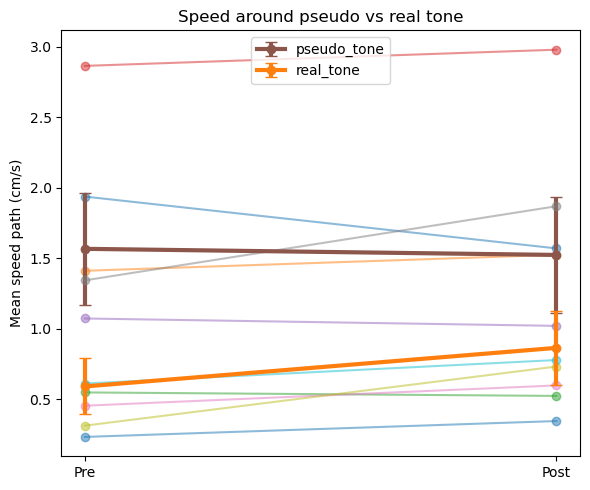

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make sure categorical order is correct
plot_df = cue_compare_rm_df.copy()

plot_df["cue_condition"] = pd.Categorical(
    plot_df["cue_condition"],
    categories=["pseudo_tone", "real_tone"],
    ordered=True
)

plot_df["window_position"] = pd.Categorical(
    plot_df["window_position"],
    categories=["pre", "post"],
    ordered=True
)

# Mean ± SEM across animals
summary = (
    plot_df
    .groupby(["cue_condition", "window_position"], observed=False)
    .agg(
        mean_speed=("mean_speed_path_cms", "mean"),
        sem_speed=("mean_speed_path_cms", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(6, 5))

x_map = {"pre": 0, "post": 1}

for cue in ["pseudo_tone", "real_tone"]:
    sub = plot_df[plot_df["cue_condition"] == cue]

    # plot each animal
    for animal, a_sub in sub.groupby("animal"):
        a_sub = a_sub.sort_values("window_position")
        xs = [x_map[w] for w in a_sub["window_position"]]
        ys = a_sub["mean_speed_path_cms"].values
        ax.plot(xs, ys, marker="o", alpha=0.5)

    # plot group mean ± sem
    s = summary[summary["cue_condition"] == cue].sort_values("window_position")
    xs = [x_map[w] for w in s["window_position"]]
    ys = s["mean_speed"].values
    yerr = s["sem_speed"].values
    ax.errorbar(xs, ys, yerr=yerr, marker="o", linewidth=3, capsize=4, label=cue)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Pre", "Post"])
ax.set_ylabel("Mean speed path (cm/s)")
ax.set_title("Speed around pseudo vs real tone")
ax.legend()
plt.tight_layout()
plt.show()

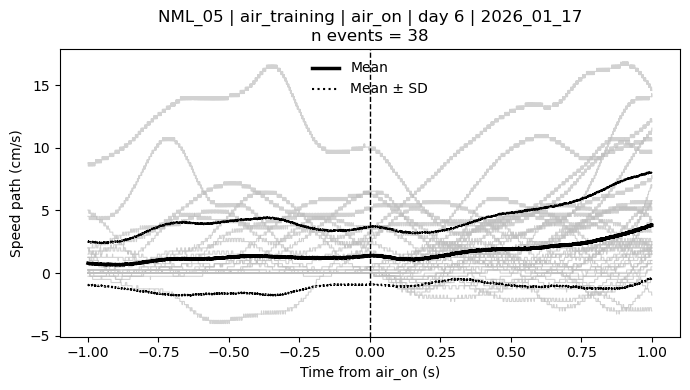

In [32]:
from src.vis.plots import plot_raw_speed_traces_around_anchor

pseudo_result = plot_raw_speed_traces_around_anchor(
    epoch_matrix_df=epoch_matrix_df,
    animal="NML_05",
    phase="air_training",
    anchor_name="air_on",
    phase_day_number_good=6,
    speed_key="speed_net_cms",
    pre_s=1.0,
    post_s=1.0,
)

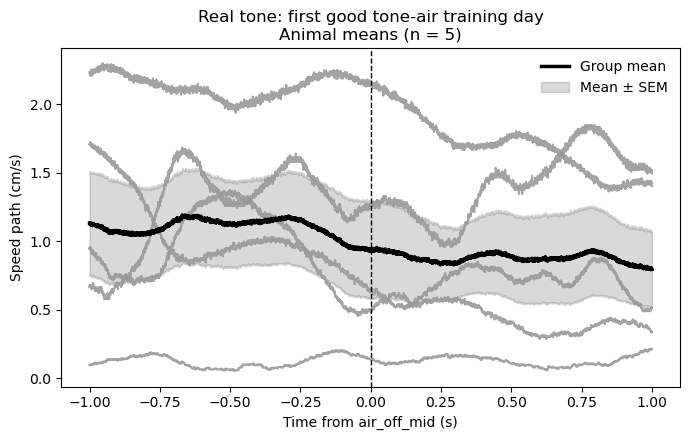

In [159]:

from src.vis.plots import plot_group_animal_mean_traces


animals = ["NML_04", "NML_05", "NML_06", "NML_07", "NML_08"]

real_group_plot = plot_group_animal_mean_traces(
    epoch_matrix_df=epoch_matrix_df,
    animals=animals,
    phase="tone_air_training",
    anchor_name="air_off_mid",
    phase_day_number_good=1,
    speed_key="speed_path_cms",
    pre_s=1.0,
    post_s=1.0,
    title="Real tone: first good tone-air training day",
    use_shaded_sem=True,
)

In [161]:
from statsmodels.stats.anova import AnovaRM
import pandas as pd
import numpy as np

# --------------------------------------------------
# 1. Select habituation LED_on / LED_off windows
# --------------------------------------------------

hab_led_df = epoch_matrix_df[
    (epoch_matrix_df["phase"] == "habituation") &
    (epoch_matrix_df["anchor_name"].isin(["LED_on", "LED_off"])) &
    (epoch_matrix_df["window_position"].isin(["pre", "post"])) &
    (epoch_matrix_df["session_time_bin"].isin(["early", "middle", "late"])) &
    (epoch_matrix_df["phase_day_bin"].isin(["early", "middle", "late"]))
].copy()

# --------------------------------------------------
# 2. Average to animal × factor-cell level
# --------------------------------------------------
# This is required for AnovaRM: one row per subject per condition cell.

hab_led_rm_df = (
    hab_led_df
    .groupby(
        [
            "animal",
            "anchor_name",
            "window_position",
            "session_time_bin",
            "phase_day_bin",
        ],
        dropna=False
    )
    .agg(
        frac_forward=("frac_forward", "mean"),
        mean_speed_path_cms=("mean_speed_path_cms", "mean"),
        frac_stationary=("frac_stationary", "mean"),
        n_windows=("frac_forward", "count"),
        n_events=("event_number", "nunique"),
        n_dates=("date", "nunique"),
    )
    .reset_index()
)

# --------------------------------------------------
# 3. Set factor orders
# --------------------------------------------------

hab_led_rm_df["anchor_name"] = pd.Categorical(
    hab_led_rm_df["anchor_name"],
    categories=["LED_on", "LED_off"],
    ordered=True
)

hab_led_rm_df["window_position"] = pd.Categorical(
    hab_led_rm_df["window_position"],
    categories=["pre", "post"],
    ordered=True
)

hab_led_rm_df["session_time_bin"] = pd.Categorical(
    hab_led_rm_df["session_time_bin"],
    categories=["early", "middle", "late"],
    ordered=True
)

hab_led_rm_df["phase_day_bin"] = pd.Categorical(
    hab_led_rm_df["phase_day_bin"],
    categories=["early", "middle", "late"],
    ordered=True
)

hab_led_rm_df.head()

,animal,anchor_name,window_position,session_time_bin,phase_day_bin,frac_forward,mean_speed_path_cms,frac_stationary,n_windows,n_events,n_dates
0,NML_04,LED_off,post,early,early,0.270541,1.128749,0.634119,74,16,6
1,NML_04,LED_off,post,early,late,0.124275,0.384247,0.778015,67,16,5
2,NML_04,LED_off,post,early,middle,0.173493,0.546093,0.754866,58,13,5
3,NML_04,LED_off,post,late,early,0.199931,0.681514,0.725814,84,26,6
4,NML_04,LED_off,post,late,late,0.263228,1.029362,0.618378,72,23,5


In [162]:
cell_check = (
    hab_led_rm_df
    .groupby("animal")
    .size()
    .reset_index(name="n_cells")
)

cell_check

,animal,n_cells
0,NML_04,36
1,NML_05,36
2,NML_06,36
3,NML_07,36
4,NML_08,36


In [163]:
aov_hab_led_frac_forward = AnovaRM(
    data=hab_led_rm_df,
    depvar="frac_forward",
    subject="animal",
    within=[
        "anchor_name",
        "window_position",
        "session_time_bin",
        "phase_day_bin",
    ]
).fit()

print(aov_hab_led_frac_forward)

                                         Anova
                                                           F Value Num DF  Den DF Pr > F
----------------------------------------------------------------------------------------
anchor_name                                                 2.3136 1.0000  4.0000 0.2029
window_position                                             1.6584 1.0000  4.0000 0.2673
session_time_bin                                            1.7610 2.0000  8.0000 0.2324
phase_day_bin                                               3.6468 2.0000  8.0000 0.0749
anchor_name:window_position                                 0.8458 1.0000  4.0000 0.4098
anchor_name:session_time_bin                                3.5543 2.0000  8.0000 0.0786
window_position:session_time_bin                            0.2964 2.0000  8.0000 0.7513
anchor_name:phase_day_bin                                   0.5720 2.0000  8.0000 0.5859
window_position:phase_day_bin                               1.4

In [164]:
aov_hab_led_speed = AnovaRM(
    data=hab_led_rm_df,
    depvar="mean_speed_path_cms",
    subject="animal",
    within=[
        "anchor_name",
        "window_position",
        "session_time_bin",
        "phase_day_bin",
    ]
).fit()

print(aov_hab_led_speed)

                                         Anova
                                                           F Value Num DF  Den DF Pr > F
----------------------------------------------------------------------------------------
anchor_name                                                 1.6861 1.0000  4.0000 0.2639
window_position                                             1.2055 1.0000  4.0000 0.3339
session_time_bin                                            1.3153 2.0000  8.0000 0.3207
phase_day_bin                                               1.9025 2.0000  8.0000 0.2109
anchor_name:window_position                                 1.2104 1.0000  4.0000 0.3330
anchor_name:session_time_bin                                2.3008 2.0000  8.0000 0.1624
window_position:session_time_bin                            0.6686 2.0000  8.0000 0.5389
anchor_name:phase_day_bin                                   2.1481 2.0000  8.0000 0.1792
window_position:phase_day_bin                               1.2

In [165]:
aov_hab_led_stationary = AnovaRM(
    data=hab_led_rm_df,
    depvar="frac_stationary",
    subject="animal",
    within=[
        "anchor_name",
        "window_position",
        "session_time_bin",
        "phase_day_bin",
    ]
).fit()

print(aov_hab_led_stationary)

                                         Anova
                                                           F Value Num DF  Den DF Pr > F
----------------------------------------------------------------------------------------
anchor_name                                                 2.5547 1.0000  4.0000 0.1852
window_position                                             0.4446 1.0000  4.0000 0.5414
session_time_bin                                            4.6932 2.0000  8.0000 0.0448
phase_day_bin                                               4.2583 2.0000  8.0000 0.0550
anchor_name:window_position                                 5.1124 1.0000  4.0000 0.0866
anchor_name:session_time_bin                                1.9774 2.0000  8.0000 0.2005
window_position:session_time_bin                            0.7319 2.0000  8.0000 0.5106
anchor_name:phase_day_bin                                   0.3133 2.0000  8.0000 0.7396
window_position:phase_day_bin                               0.2

In [166]:
hab_led_rm_df.groupby(
    ["phase_day_bin", "session_time_bin"],
    observed=False
).agg(
    mean_speed=("mean_speed_path_cms", "mean"),
    sem_speed=("mean_speed_path_cms", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    n=("animal", "nunique"),
).reset_index()

,phase_day_bin,session_time_bin,mean_speed,sem_speed,n
0,early,early,0.793399,0.169595,5
1,early,middle,0.639225,0.155822,5
2,early,late,0.655485,0.161944,5
3,middle,early,1.509667,0.374586,5
4,middle,middle,1.610955,0.432988,5
5,middle,late,1.372035,0.385381,5
6,late,early,3.118417,0.984063,5
7,late,middle,2.894085,0.949307,5
8,late,late,3.306089,0.975954,5


In [169]:
hab_led_rm_df.groupby(
    ["phase_day_bin", "session_time_bin"],
    observed=False
).agg(
    mean_stationary=("frac_stationary", "mean"),
    sem_stationary=("frac_stationary", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    n=("animal", "nunique"),
).reset_index()

,phase_day_bin,session_time_bin,mean_stationary,sem_stationary,n
0,early,early,0.743377,0.033617,5
1,early,middle,0.788882,0.029388,5
2,early,late,0.784178,0.032021,5
3,middle,early,0.642996,0.049798,5
4,middle,middle,0.675941,0.044536,5
5,middle,late,0.715470,0.046217,5
6,late,early,0.556810,0.066325,5
7,late,middle,0.596682,0.069514,5
8,late,late,0.554352,0.065210,5


In [171]:
hab_led_rm_df = (
    hab_led_df
    .groupby(
        [
            "animal",
            "anchor_name",
            "window_position",
            "session_time_bin",
            "phase_day_bin",
        ],
        dropna=False
    )
    .agg(
        frac_forward=("frac_forward", "mean"),
        frac_backward=("frac_backward", "mean"),
        frac_low_net_movement=("frac_low_net_movement", "mean"),
        frac_stationary=("frac_stationary", "mean"),
        frac_moving=("frac_moving", "mean"),
        mean_speed_path_cms=("mean_speed_path_cms", "mean"),
        n_windows=("frac_forward", "count"),
        n_events=("event_number", "nunique"),
        n_dates=("date", "nunique"),
    )
    .reset_index()
)

hab_direction_summary = (
    hab_led_rm_df
    .groupby(
        ["phase_day_bin", "session_time_bin"],
        observed=False
    )
    .agg(
        mean_forward=("frac_forward", "mean"),
        sem_forward=("frac_forward", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        mean_backward=("frac_backward", "mean"),
        sem_backward=("frac_backward", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        mean_low_net=("frac_low_net_movement", "mean"),
        sem_low_net=("frac_low_net_movement", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("animal", "nunique"),
    )
    .reset_index()
)

hab_direction_summary

,phase_day_bin,session_time_bin,mean_forward,sem_forward,mean_backward,sem_backward,mean_low_net,sem_low_net,n
0,early,early,0.181072,0.031190,0.075551,0.005986,0.0,0.0,5
1,early,late,0.157377,0.029224,0.058445,0.005785,0.0,0.0,5
2,early,middle,0.150343,0.026523,0.060775,0.005820,0.0,0.0,5
3,late,early,0.372188,0.071777,0.071003,0.009953,0.0,0.0,5
4,late,late,0.391422,0.067092,0.054226,0.008544,0.0,0.0,5
5,late,middle,0.343550,0.069839,0.059768,0.009370,0.0,0.0,5
6,middle,early,0.282653,0.049029,0.074351,0.006081,0.0,0.0,5
7,middle,late,0.233890,0.042326,0.050641,0.008394,0.0,0.0,5
8,middle,middle,0.266960,0.044383,0.057099,0.008454,0.0,0.0,5


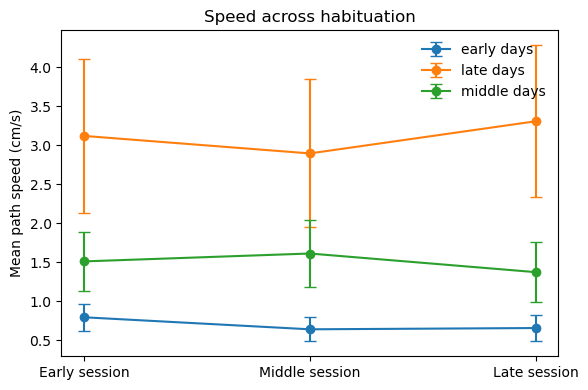

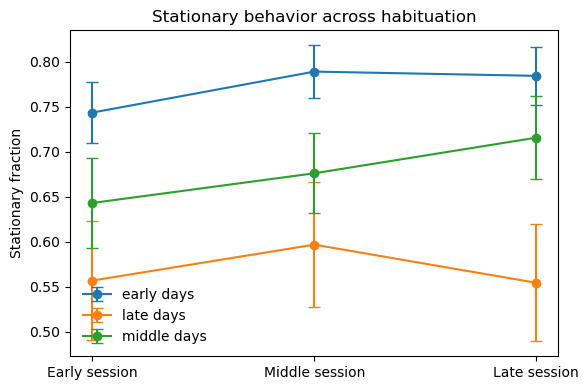

In [172]:
import matplotlib.pyplot as plt

def plot_hab_summary(summary_df, y_col, sem_col, ylabel, title):
    fig, ax = plt.subplots(figsize=(6, 4))

    x_order = ["early", "middle", "late"]
    x = np.arange(len(x_order))

    for day_bin, sub in summary_df.groupby("phase_day_bin", observed=False):
        sub = sub.set_index("session_time_bin").loc[x_order].reset_index()

        ax.errorbar(
            x,
            sub[y_col],
            yerr=sub[sem_col],
            marker="o",
            capsize=4,
            label=f"{day_bin} days"
        )

    ax.set_xticks(x)
    ax.set_xticklabels(["Early session", "Middle session", "Late session"])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


speed_summary = (
    hab_led_rm_df
    .groupby(["phase_day_bin", "session_time_bin"], observed=False)
    .agg(
        mean_speed=("mean_speed_path_cms", "mean"),
        sem_speed=("mean_speed_path_cms", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("animal", "nunique"),
    )
    .reset_index()
)

stationary_summary = (
    hab_led_rm_df
    .groupby(["phase_day_bin", "session_time_bin"], observed=False)
    .agg(
        mean_stationary=("frac_stationary", "mean"),
        sem_stationary=("frac_stationary", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
        n=("animal", "nunique"),
    )
    .reset_index()
)

plot_hab_summary(
    speed_summary,
    y_col="mean_speed",
    sem_col="sem_speed",
    ylabel="Mean path speed (cm/s)",
    title="Speed across habituation"
)

plot_hab_summary(
    stationary_summary,
    y_col="mean_stationary",
    sem_col="sem_stationary",
    ylabel="Stationary fraction",
    title="Stationary behavior across habituation"
)

In [9]:
import sys
from pathlib import Path

# Find the project root that contains the src folder
current = Path.cwd().resolve()

for p in [current] + list(current.parents):
    if (p / "src").exists():
        repo_root = p
        break
else:
    raise FileNotFoundError("Could not find a folder containing 'src'.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Current working directory:", current)
print("Added repo root:", repo_root)
print("src exists:", (repo_root / "src").exists())

from pathlib import Path
import numpy as np
import pandas as pd

import src.utils.pdata_io as pdio
from src.proc.extract_epoch_windows import load_epoch_windows

data_root, pdata_root, cc_data = pdio.load_project_context()

Current working directory: /home/nmldata2/ccaw/Python/notebooks
Added repo root: /home/nmldata2/ccaw/Python
src exists: True
/home/nmldata2/ccaw/Python
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl


[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl


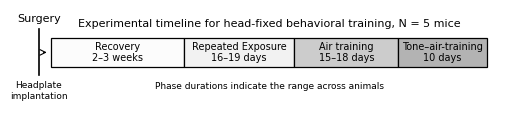

In [26]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# --------------------------------------------------
# Output folder
# --------------------------------------------------
try:
    fig_dir = Path(fig_dir_str)
except NameError:
    fig_dir = Path("figure_drafts")

fig_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Experimental phase information
# --------------------------------------------------
N_animals = 5

# Durations are used only for schematic proportional widths
# Recovery is shown as 21 days to represent 2–3 weeks
phases = [
    {
        "name": "Recovery",
        "duration": 21,
        "label": "Recovery\n2–3 weeks",
        "facecolor": "0.99",
        "hatch": None,
    },
    {
        "name": "Habituation",
        "duration": 17.5,
        "label": "Repeated Exposure\n16–19 days",
        "facecolor": "0.95",
        "hatch": None,
    },
    {
        "name": "Air training",
        "duration": 16.5,
        "label": "Air training\n15–18 days",
        "facecolor": "0.8",
        "hatch": None,
    },
    {
        "name": "Tone–air training",
        "duration": 14,
        "label": "Tone–air-training\n10 days",
        "facecolor": "0.7",
        "hatch": None,
    },
]

# --------------------------------------------------
# Build timeline coordinates
# --------------------------------------------------
surgery_x = 0
gap_after_surgery = 2.0
x0 = surgery_x + gap_after_surgery

bar_y = 0.45
bar_h = 0.35

timeline = []
current_x = x0

for phase in phases:
    start = current_x
    end = start + phase["duration"]
    timeline.append((start, end, phase))
    current_x = end

timeline_end = current_x + 2

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 1))

# --------------------------------------------------
# Surgery marker
# --------------------------------------------------
ax.plot(
    [surgery_x, surgery_x],
    [bar_y - 0.10, bar_y + bar_h + 0.12],
    color="black",
    linewidth=1.2
)

ax.text(
    surgery_x,
    bar_y + bar_h + 0.18,
    "Surgery",
    ha="center",
    va="bottom",
    fontsize=8
)

ax.text(
    surgery_x,
    bar_y - 0.18,
    "Headplate\nimplantation",
    ha="center",
    va="top",
    fontsize=6.5
)

# --------------------------------------------------
# Phase rectangles
# --------------------------------------------------
for start, end, phase in timeline:
    ax.add_patch(Rectangle(
        (start, bar_y),
        end - start,
        bar_h,
        facecolor=phase["facecolor"],
        edgecolor="black",
        linewidth=0.9,
        hatch=phase["hatch"]
    ))

    ax.text(
        (start + end) / 2,
        bar_y + bar_h / 2,
        phase["label"],
        ha="center",
        va="center",
        fontsize=7
    )

# --------------------------------------------------
# Arrows between surgery and phases
# --------------------------------------------------
ax.annotate(
    "",
    xy=(x0 - 0.3, bar_y + bar_h / 2),
    xytext=(surgery_x + 0.3, bar_y + bar_h / 2),
    arrowprops=dict(arrowstyle="->", linewidth=0.8, color="black")
)

# --------------------------------------------------
# Main title / N label
# --------------------------------------------------
ax.text(
    (surgery_x + timeline_end) / 2,
    0.92,
    f"Experimental timeline for head-fixed behavioral training, N = {N_animals} mice",
    ha="center",
    va="bottom",
    fontsize=8
)

# --------------------------------------------------
# Optional note
# --------------------------------------------------
ax.text(
    (surgery_x + timeline_end) / 2,
    0.2,
    "Phase durations indicate the range across animals",
    ha="center",
    va="center",
    fontsize=6.5
)

# --------------------------------------------------
# Formatting
# --------------------------------------------------
ax.set_xlim(-2, timeline_end)
ax.set_ylim(0.0, 1.15)
ax.axis("off")

fig.tight_layout(pad=0.2)

import src.utils.pdata_io as pdio

data_root, pdata_root, cc_data = pdio.load_project_context()


fig_dir = Path(pdata_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Save
# --------------------------------------------------
fig.savefig(fig_dir / "Figure_experimental_timeline_schematic.pdf",
            bbox_inches="tight")
fig.savefig(fig_dir / "Figure_experimental_timeline_schematic.png",
            dpi=600, bbox_inches="tight")

plt.show()

In [11]:
fig_dir

PosixPath('/mnt/pdata/Classical_Conditioning/figures')

Available anchors:
['LED_off', 'LED_off_mid', 'LED_on', 'LED_on_mid', 'pseudo_tone_off', 'pseudo_tone_on']
Using: NML_06 2025_12_27 habituation day 1
Using event_number: 0


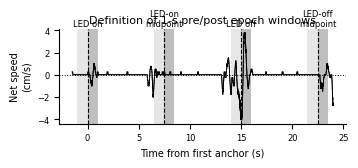

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

epoch_matrix_df = encoder_epoch_df.copy()

# --------------------------------------------------
# Settings
# --------------------------------------------------

phase = "habituation"
animal = "NML_06"          # change if needed
phase_day_number_good = 1  # change if needed
speed_key = "speed_net_cms"
pre_s = 1.0
post_s = 1.0

try:
    fig_dir = Path(fig_dir_str)
except NameError:
    fig_dir = Path("figure_drafts")

fig_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Helper: detect anchor names used in your dataframe
# --------------------------------------------------

def get_anchor_order_for_phase(epoch_matrix_df, phase):
    available = sorted(
        epoch_matrix_df.loc[
            epoch_matrix_df["phase"] == phase,
            "anchor_name"
        ].dropna().unique()
    )

    print("Available anchors:")
    print(available)

    candidate_orders = [
        ["led_on", "led_on_mid", "led_off", "led_off_mid"],
        ["LED_on", "LED_on_mid", "LED_off", "LED_off_mid"],
        ["air_on", "air_on_mid", "air_off", "air_off_mid"],
        ["Air_on", "Air_on_mid", "Air_off", "Air_off_mid"],
    ]

    for cand in candidate_orders:
        if all(a in available for a in cand):
            return cand

    raise ValueError(
        "Could not automatically detect the four anchor names. "
        "Check the printed available anchors and set anchor_order manually."
    )

anchor_order = get_anchor_order_for_phase(epoch_matrix_df, phase)


anchor_labels = {
    anchor_order[0]: "LED on",
    anchor_order[1]: "LED-on\nmidpoint",
    anchor_order[2]: "LED off",
    anchor_order[3]: "LED-off\nmidpoint",
}

# --------------------------------------------------
# Select one animal/day
# --------------------------------------------------

sub = epoch_matrix_df[
    (epoch_matrix_df["animal"] == animal) &
    (epoch_matrix_df["phase"] == phase) &
    # (epoch_matrix_df["phase_day_number_good"] == phase_day_number_good) &
    (epoch_matrix_df["anchor_name"].isin(anchor_order))
].copy()

if sub.empty:
    raise ValueError("No rows found for this animal / phase / day.")

dates = sorted(sub["date"].dropna().unique())
date = dates[0]
sub = sub[sub["date"] == date].copy()

print("Using:", animal, date, phase, "day", phase_day_number_good)

# --------------------------------------------------
# Pick one complete virtual cycle/event with all 4 anchors
# --------------------------------------------------

complete_events = (
    sub.groupby("event_number")["anchor_name"]
    .nunique()
    .reset_index(name="n_anchors")
)

complete_events = complete_events[complete_events["n_anchors"] == 4]

if complete_events.empty:
    raise ValueError("No event_number has all four anchors.")

event_number = complete_events.iloc[0]["event_number"]
print("Using event_number:", event_number)

ev = sub[sub["event_number"] == event_number].copy()

anchor_times = (
    ev[["anchor_name", "anchor_time_s"]]
    .drop_duplicates()
    .set_index("anchor_name")
    .loc[anchor_order]["anchor_time_s"]
)

# --------------------------------------------------
# Load raw net speed
# --------------------------------------------------

b = pdio.load_behavior_h5(
    animal,
    date,
    keys=[speed_key, "fs"]
)

speed = np.asarray(b[speed_key]).reshape(-1)
fs = float(np.asarray(b["fs"]).squeeze())

t = np.arange(len(speed)) / fs

# --------------------------------------------------
# Plot segment around this virtual cycle
# --------------------------------------------------

x_start = anchor_times.iloc[0] - 1.5
x_end = anchor_times.iloc[-1] + 1.5

idx = (t >= x_start) & (t <= x_end)

fig, ax = plt.subplots(figsize=(3.5, 1.6))

ax.plot(
    t[idx] - anchor_times.iloc[0],
    speed[idx],
    linewidth=0.6,
    color="black"
)

# Anchor windows
for anchor_name in anchor_order:
    at = anchor_times.loc[anchor_name]
    x0 = at - anchor_times.iloc[0]

    # Pre 1-s window
    ax.axvspan(
        x0 - pre_s,
        x0,
        facecolor="0.90",
        edgecolor="none",
        alpha=1.0
    )

    # Post 1-s window
    ax.axvspan(
        x0,
        x0 + post_s,
        facecolor="0.75",
        edgecolor="none",
        alpha=1.0
    )

    # Anchor line
    ax.axvline(
        x0,
        linestyle="--",
        linewidth=0.8,
        color="black"
    )

    ax.text(
        x0,
        ax.get_ylim()[1],
        anchor_labels[anchor_name],
        ha="center",
        va="bottom",
        fontsize=6
    )

# Replot speed on top of shaded windows
ax.plot(
    t[idx] - anchor_times.iloc[0],
    speed[idx],
    linewidth=0.6,
    color="black"
)

ax.axhline(0, linestyle=":", linewidth=0.7, color="black")

ax.set_xlabel("Time from first anchor (s)", fontsize=7)
ax.set_ylabel("Net speed\n(cm/s)", fontsize=7)
ax.tick_params(axis="both", labelsize=6)

ax.set_title(
    "Definition of 1-s pre/post epoch windows",
    fontsize=8,
    pad=4
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout(pad=0.4)

fig.savefig(
    fig_dir / "Figure_epoch_window_definition_raw_net_speed.pdf",
    bbox_inches="tight"
)

# fig.savefig(
#     fig_dir / "Figure_epoch_window_definition_raw_net_speed.png",
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()

In [18]:
def plot_raw_net_speed_around_4anchors_one_animal(
    epoch_matrix_df,
    animal,
    phase="habituation",
    phase_day_number_good=1,
    speed_key="speed_net_cms",
    pre_s=1.0,
    post_s=1.0,
    max_traces=None,
    show_individual_traces=False,
    fig_dir=None,
):
    """
    Plot raw net speed around the four virtual-cycle anchors for one animal/day.

    Thin gray lines = individual events/trials, optional
    Black line = mean
    Gray band = mean ± SD
    """

    anchor_order = get_anchor_order_for_phase(epoch_matrix_df, phase)

    anchor_labels = {
        anchor_order[0]: "LED on",
        anchor_order[1]: "LED-on\nmidpoint",
        anchor_order[2]: "LED off",
        anchor_order[3]: "LED-off\nmidpoint",
    }

    sub_all = epoch_matrix_df[
        (epoch_matrix_df["animal"] == animal) &
        (epoch_matrix_df["phase"] == phase) &
        (epoch_matrix_df["phase_day_number_good"] == phase_day_number_good) &
        (epoch_matrix_df["anchor_name"].isin(anchor_order))
    ].copy()

    if sub_all.empty:
        raise ValueError("No rows found for this animal / phase / day.")

    date = sorted(sub_all["date"].dropna().unique())[0]
    sub_all = sub_all[sub_all["date"] == date].copy()

    b = pdio.load_behavior_h5(
        animal,
        date,
        keys=[speed_key, "fs"]
    )

    speed = np.asarray(b[speed_key]).reshape(-1)
    fs = float(np.asarray(b["fs"]).squeeze())

    n_pre = int(round(pre_s * fs))
    n_post = int(round(post_s * fs))
    expected_n = n_pre + n_post

    rel_t = np.arange(-n_pre, n_post) / fs

    traces_by_anchor = {}

    for anchor_name in anchor_order:

        sub = sub_all[sub_all["anchor_name"] == anchor_name].copy()

        anchor_events = (
            sub[
                [
                    "event_number",
                    "anchor_name",
                    "anchor_time_s",
                ]
            ]
            .drop_duplicates()
            .sort_values("event_number")
            .reset_index(drop=True)
        )

        if max_traces is not None:
            anchor_events = anchor_events.iloc[:max_traces].copy()

        traces = []

        for _, ev in anchor_events.iterrows():

            anchor_time = ev["anchor_time_s"]

            if not np.isfinite(anchor_time):
                continue

            anchor_idx = int(round(anchor_time * fs))

            start_idx = anchor_idx - n_pre
            end_idx = anchor_idx + n_post

            if start_idx < 0 or end_idx > len(speed):
                continue

            trace = speed[start_idx:end_idx]

            if len(trace) == expected_n:
                traces.append(trace)

        if len(traces) > 0:
            traces_by_anchor[anchor_name] = np.vstack(traces)
        else:
            traces_by_anchor[anchor_name] = np.empty((0, expected_n))

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(6.8, 1.7),
        sharex=True,
        sharey=True
    )

    for ax, anchor_name in zip(axes, anchor_order):

        traces = traces_by_anchor[anchor_name]

        if traces.shape[0] == 0:
            ax.text(0.5, 0.5, "No traces", ha="center", va="center", transform=ax.transAxes)
            continue

        mean_trace = np.nanmean(traces, axis=0)
        sd_trace = np.nanstd(traces, axis=0)

        if show_individual_traces:
            for tr in traces:
                ax.plot(rel_t, tr, color="0.75", linewidth=0.35, alpha=0.35)

        ax.fill_between(
            rel_t,
            mean_trace - sd_trace,
            mean_trace + sd_trace,
            color="0.80",
            linewidth=0
        )

        ax.plot(
            rel_t,
            mean_trace,
            color="black",
            linewidth=1.2
        )

        ax.axvline(0, linestyle="--", linewidth=0.8, color="black")
        ax.axhline(0, linestyle=":", linewidth=0.7, color="black")

        ax.set_title(anchor_labels[anchor_name], fontsize=7, pad=3)
        ax.set_xlabel("Time (s)", fontsize=7)
        ax.tick_params(axis="both", labelsize=6)

        ax.text(
            0.96,
            0.05,
            f"n={traces.shape[0]}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=5.5
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Net speed\n(cm/s)", fontsize=7)

    fig.suptitle(
        f"{animal} | {phase} | day {phase_day_number_good} | {date}",
        fontsize=8,
        y=1.05
    )

    fig.tight_layout(pad=0.35)

    if fig_dir is not None:
        fig_dir = Path(fig_dir)
        fig_dir.mkdir(parents=True, exist_ok=True)

        fname = f"Figure_raw_net_speed_4anchors_{animal}_{phase}_day{phase_day_number_good}_{date}"

        fig.savefig(fig_dir / f"{fname}.pdf", bbox_inches="tight")
        fig.savefig(fig_dir / f"{fname}.png", dpi=600, bbox_inches="tight")

    plt.show()

    return {
        "fig": fig,
        "axes": axes,
        "traces_by_anchor": traces_by_anchor,
        "time": rel_t,
        "animal": animal,
        "date": date,
        "phase": phase,
        "phase_day_number_good": phase_day_number_good,
    }

In [19]:
# --------------------------------------------------
# Binned epoch summaries for plotting dots
# --------------------------------------------------

outcome = "frac_moving"  # or "frac_forward", "mean_speed_path_cms"

df = hab_epoch_df_20min.copy()

# Define exposure groups
q1 = df["exposure_session"].quantile(1/3)
q2 = df["exposure_session"].quantile(2/3)

df["exposure_label"] = np.select(
    [
        df["exposure_session"] <= q1,
        df["exposure_session"] >= q2,
    ],
    [
        "Early exposure",
        "Late exposure",
    ],
    default="Mean exposure"
)

# Define within-session 1-min bins
df["session_time_bin"] = np.floor(df["session_time_min"]).astype(int)

# Each row in raw_bin_df is one plotted dot
raw_bin_df = (
    df
    .groupby(["exposure_label", "session_time_bin"], observed=True)
    .agg(
        y_mean=(outcome, "mean"),
        n_epochs=(outcome, "count"),
    )
    .reset_index()
)

display(raw_bin_df.head())

NameError: name 'hab_epoch_df_20min' is not defined